In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
# Load data
df = pd.read_csv('/Users/mitchelljohnson/Downloads/fake_news_dataset.csv')

In [47]:
# Keep only relevant columns
columns_to_keep = ['id', 'title', 'author', 'source', 'category',
                   'readability_score', 'political_bias', 'trust_score', 'label']
df = df[columns_to_keep]

In [49]:
# Drop rows with missing or invalid labels
df = df.dropna(subset=['label'])
df['label'] = df['label'].str.strip().str.lower()
df = df[df['label'].isin(['fake', 'real'])]
df['label'] = df['label'].map({'fake': 1, 'real': 0})

In [51]:
# Drop rows with missing values in selected features
df = df.dropna(subset=['readability_score', 'trust_score', 'political_bias'])

In [35]:
# Drop any remaining rows with NaN values
df = df.dropna()

In [53]:
# Encode 'political_bias' using LabelEncoder
le = LabelEncoder()
df['political_bias_encoded'] = le.fit_transform(df['political_bias'])

In [57]:
# Define features and target (use only numeric features)
X = df[['readability_score', 'trust_score', 'political_bias_encoded']]
y = df['label']

In [59]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [61]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [63]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

In [65]:
# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4975

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.38      0.43       395
           1       0.50      0.61      0.55       405

    accuracy                           0.50       800
   macro avg       0.50      0.50      0.49       800
weighted avg       0.50      0.50      0.49       800



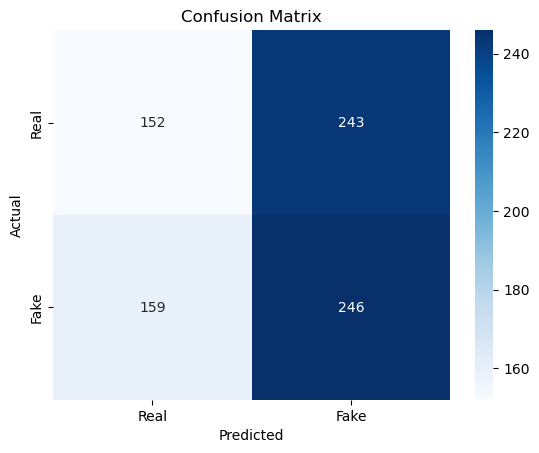

In [67]:
# Confusion Matrix Heatmap
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()